# Compare turbulent heat fluxes and related variables

Author: Ziqi Yin

Last edited: Jun 1, 2026

Description: comparing turbulent heat fluxes and related variables over the Greenland Ice Sheet in CESM2 LENS2 between the historical period (1975-2014) and the future scenario (2061-2100).

In [1]:
import numpy as np
import numpy.ma as ma
import xarray as xr
from statistics import mode
import pandas as pd
from scipy import signal
from scipy import interpolate
from scipy import stats
import seaborn as sns  ### seaborn just makes things pretty -- no new typing
from math import radians, sin, cos, sqrt, atan2

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as colors
from matplotlib.collections import PolyCollection
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import cartopy
import cartopy.crs as ccrs
crs_np = ccrs.NorthPolarStereo(central_longitude=0)
crs_ll = ccrs.PlateCarree()
from cartopy.util import add_cyclic_point
#from holoviews.operation.datashader import datashade, rasterize, regrid

home_dir = '/glade/work/ziqiyin/'
import sys  
sys.path.insert(0, home_dir)
sys.path.append(home_dir + 'function/')
from functions import *

import warnings
warnings.filterwarnings('ignore')

# For regridding
import os
import ESMF
import xesmf as xe

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/ziqiyin/conda-envs/my-npl-202306a/share/proj failed


### Read data

In [6]:
## LH related variables
data_dir = '/glade/derecho/scratch/ziqiyin/2023-GrIS-melt-causality/LENS2/mergetime/'

PCT_LANDUNIT_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.clm2.h0.PCT_LANDUNIT.197001-201412.nc')['PCT_LANDUNIT'] #
PCT_LANDUNIT_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.clm2.h0.PCT_LANDUNIT.205501-210012.nc')['PCT_LANDUNIT']
TS_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.cam.h0.TS.197001-201412.nc')['TS'] #[K]
TS_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.cam.h0.TS.205501-210012.nc')['TS']

dates1 = pd.date_range("1970-01-01", periods=45*12, freq='M')
dates2 = pd.date_range("2055-01-01", periods=46*12, freq='M')

PCT_LANDUNIT_monthly_1970_2014['time'] = dates1
PCT_LANDUNIT_monthly_2055_2100['time'] = dates2
TS_monthly_1970_2014['time'] = dates1
TS_monthly_2055_2100['time'] = dates2

PCT_LANDUNIT_monthly_1975_2014 = PCT_LANDUNIT_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))
TS_monthly_1975_2014 = TS_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))

PCT_LANDUNIT_monthly_2061_2100 = PCT_LANDUNIT_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))
TS_monthly_2061_2100 = TS_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))

f09_lon = PCT_LANDUNIT_monthly_1970_2014.lon
f09_lat = PCT_LANDUNIT_monthly_1970_2014.lat

In [7]:
TS_monthly_1975_2014['lat'] = f09_lat.values
TS_monthly_2061_2100['lat'] = f09_lat.values

In [19]:
## SMB variables
data_dir = '/glade/derecho/scratch/ziqiyin/2023-GrIS-melt-causality/LENS2/mergetime/'

RAIN_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.clm2.h0.RAIN.197001-201412.nc')['RAIN'] #[mm/s]
RAIN_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.clm2.h0.RAIN.205501-210012.nc')['RAIN']
SNOW_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.clm2.h0.SNOW.197001-201412.nc')['SNOW']
SNOW_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.clm2.h0.SNOW.205501-210012.nc')['SNOW']
QRUNOFF_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.clm2.h0.QRUNOFF_ICE.197001-201412.nc')['QRUNOFF_ICE']
QRUNOFF_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.clm2.h0.QRUNOFF_ICE.205501-210012.nc')['QRUNOFF_ICE']
QFLX_EVAP_TOT_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.clm2.h0.QFLX_EVAP_TOT.197001-201412.nc')['QFLX_EVAP_TOT']
QFLX_EVAP_TOT_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.clm2.h0.QFLX_EVAP_TOT.205501-210012.nc')['QFLX_EVAP_TOT']
QSNOMELT_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.clm2.h0.QSNOMELT_ICE.197001-201412.nc')['QSNOMELT_ICE']
QSNOMELT_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.clm2.h0.QSNOMELT_ICE.205501-210012.nc')['QSNOMELT_ICE']
QICE_MELT_monthly_1970_2014 = xr.open_dataset(data_dir+'b.e21.BHISTcmip6.f09_g17.LE2-ensmean.clm2.h0.QICE_MELT.197001-201412.nc')['QICE_MELT']
QICE_MELT_monthly_2055_2100 = xr.open_dataset(data_dir+'b.e21.BSSP370cmip6.f09_g17.LE2-ensmean.clm2.h0.QICE_MELT.205501-210012.nc')['QICE_MELT']

dates1 = pd.date_range("1970-01-01", periods=45*12, freq='M')
dates2 = pd.date_range("2055-01-01", periods=46*12, freq='M')

RAIN_monthly_1970_2014['time'] = dates1
RAIN_monthly_2055_2100['time'] = dates2
SNOW_monthly_1970_2014['time'] = dates1
SNOW_monthly_2055_2100['time'] = dates2
QRUNOFF_monthly_1970_2014['time'] = dates1
QRUNOFF_monthly_2055_2100['time'] = dates2
QFLX_EVAP_TOT_monthly_1970_2014['time'] = dates1
QFLX_EVAP_TOT_monthly_2055_2100['time'] = dates2
QSNOMELT_monthly_1970_2014['time'] = dates1
QSNOMELT_monthly_2055_2100['time'] = dates2
QICE_MELT_monthly_1970_2014['time'] = dates1
QICE_MELT_monthly_2055_2100['time'] = dates2

RAIN_monthly_1975_2014 = RAIN_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))
SNOW_monthly_1975_2014 = SNOW_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))
QRUNOFF_monthly_1975_2014 = QRUNOFF_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))
QFLX_EVAP_TOT_monthly_1975_2014 = QFLX_EVAP_TOT_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))
QSNOMELT_monthly_1975_2014 = QSNOMELT_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))
QICE_MELT_monthly_1975_2014 = QICE_MELT_monthly_1970_2014.sel(time=slice('1975-01-01','2014-12-31'))

RAIN_monthly_2061_2100 = RAIN_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))
SNOW_monthly_2061_2100 = SNOW_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))
QRUNOFF_monthly_2061_2100 = QRUNOFF_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))
QFLX_EVAP_TOT_monthly_2061_2100 = QFLX_EVAP_TOT_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))
QSNOMELT_monthly_2061_2100 = QSNOMELT_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))
QICE_MELT_monthly_2061_2100 = QICE_MELT_monthly_2055_2100.sel(time=slice('2061-01-01','2100-12-31'))

smb_monthly_1975_2014 = RAIN_monthly_1975_2014 + SNOW_monthly_1975_2014 - QRUNOFF_monthly_1975_2014 - QFLX_EVAP_TOT_monthly_1975_2014
smb_monthly_2061_2100 = RAIN_monthly_2061_2100 + SNOW_monthly_2061_2100 - QRUNOFF_monthly_2061_2100 - QFLX_EVAP_TOT_monthly_2061_2100

Melt_monthly_1975_2014 = QSNOMELT_monthly_1975_2014 + QICE_MELT_monthly_1975_2014
Melt_monthly_2061_2100 = QSNOMELT_monthly_2061_2100 + QICE_MELT_monthly_2061_2100

In [8]:
## Mask
# f09
# Generate Greenland mask
f09_mask_file1 = '/glade/work/aherring/grids/uniform-res/f09/clm_surfdata_5_0/surfdata_f09_hist_78pfts_CMIP6_simyr1850_c200429.nc'
f09_GrIS_mask0 = xr.open_dataset(f09_mask_file1)['GLACIER_REGION']
f09_GrIS_mask0 = xr.where(f09_GrIS_mask0==2, 1, np.nan)
# Glacier fraction of land area
f09_glacier_frac_monthly_1975_2014 = PCT_LANDUNIT_monthly_1975_2014[:,3,:,:]
f09_glacier_frac_monthly_2061_2100 = PCT_LANDUNIT_monthly_2061_2100[:,3,:,:]
# Land fraction of grid cell
f09_mask_file3 = '/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001/lnd/proc/tseries/month_1/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001.clm2.h0.RAIN.000101-005012.nc'
f09_land_frac = xr.open_dataset(f09_mask_file3)['landfrac'] #fraction of grid cell that is active

GrIS_mask_monthly_1975_2014 = f09_GrIS_mask0.values * f09_glacier_frac_monthly_1975_2014 * f09_land_frac.values / 100
GrIS_mask_monthly_2061_2100 = f09_GrIS_mask0.values * f09_glacier_frac_monthly_2061_2100 * f09_land_frac.values / 100

In [9]:
## Area
Re = 6371.22 * 1e3 #[m]

f09_mask_file3 = '/glade/p/cesmdata/cseg/inputdata/share/domains/domain.lnd.fv0.9x1.25_gx1v7.151020.nc'
f09_area = xr.open_dataset(f09_mask_file3)['area'] #[Radian2]
f09_area = f09_area.values * Re**2

## Calculate

In [20]:
## Ablation mask
days_in_month = smb_monthly_1975_2014.time.dt.days_in_month
year = smb_monthly_1975_2014.time.dt.year
smb_yearly_1975_2014 = (smb_monthly_1975_2014 * days_in_month).groupby(year).sum()
smb_yearly_mean_1975_2014 = smb_yearly_1975_2014.mean(dim='year')

days_in_month = smb_monthly_2061_2100.time.dt.days_in_month
year = smb_monthly_2061_2100.time.dt.year
smb_yearly_2061_2100 = (smb_monthly_2061_2100 * days_in_month).groupby(year).sum()
smb_yearly_mean_2061_2100 = smb_yearly_2061_2100.mean(dim='year')

GrIS_ablation_mask_monthly_1975_2014 = GrIS_mask_monthly_1975_2014.where(smb_yearly_mean_1975_2014 < 0)
GrIS_ablation_mask_monthly_2061_2100 = GrIS_mask_monthly_2061_2100.where(smb_yearly_mean_2061_2100 < 0)

### JJA mean fields

In [10]:
TS_monthly_1975_2014_masked = TS_monthly_1975_2014.where(GrIS_mask_monthly_1975_2014 > 0)
TS_monthly_2061_2100_masked = TS_monthly_2061_2100.where(GrIS_mask_monthly_2061_2100 > 0)

In [11]:
def weighted_summer_mean(data):

    # Step 1: Calculate the number of days in each month
    days_in_month = data['time'].dt.days_in_month

    # Step 2: Select only summer months (June, July, August)
    summer_months = data['time'].dt.month.isin([6, 7, 8])

    # Step 3: Multiply the data by the number of days in each month (weighted data)
    weighted_data = data.where(summer_months, drop=True) * days_in_month.where(summer_months, drop=True)

    # Step 4: Calculate the weighted summer sum and total days in the summer
    summer_sum = weighted_data.sum(dim='time')
    total_days_in_summer = days_in_month.where(summer_months, drop=True).sum(dim='time')

    # Step 5: Calculate the weighted summer mean
    weighted_summer_mean = summer_sum / total_days_in_summer

    return weighted_summer_mean

In [12]:
TS_monthly_1975_2014_masked_JJA_mean = weighted_summer_mean(TS_monthly_1975_2014_masked - 273.15) #[deg C]
TS_monthly_2061_2100_masked_JJA_mean = weighted_summer_mean(TS_monthly_2061_2100_masked - 273.15) #[deg C]

### Monthly mean fields

In [13]:
time = TS_monthly_1975_2014_masked.time
TS_monthly_mean_1975_2014_masked = TS_monthly_1975_2014_masked.groupby(time.dt.month).mean()

time = TS_monthly_2061_2100_masked.time
TS_monthly_mean_2061_2100_masked = TS_monthly_2061_2100_masked.groupby(time.dt.month).mean()

In [22]:
smb_ICE_yearly_mean_1975_2014_ensmean = xr.open_dataset(home_dir+'2023-GrIS-melt-causality/data/LENS2/smb_ICE_yearly_mean_1975_2014_ensmean.nc')['SMB']
smb_ICE_yearly_mean_2061_2100_ensmean = xr.open_dataset(home_dir+'2023-GrIS-melt-causality/data/LENS2/smb_ICE_yearly_mean_2061_2100_ensmean.nc')['SMB']

smb_ICE_yearly_mean_1975_2014_ensmean_masked = smb_ICE_yearly_mean_1975_2014_ensmean.where(GrIS_mask_monthly_1975_2014[0] > 0)
smb_ICE_yearly_mean_2061_2100_ensmean_masked = smb_ICE_yearly_mean_2061_2100_ensmean.where(GrIS_mask_monthly_2061_2100[0] > 0)

## Plot

### Monthly mean fields

In [14]:
# Set Polar Sterographic Projection definition
polar_stereographic = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-45.0,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70.0,
    globe=ccrs.Globe('WGS84')
)

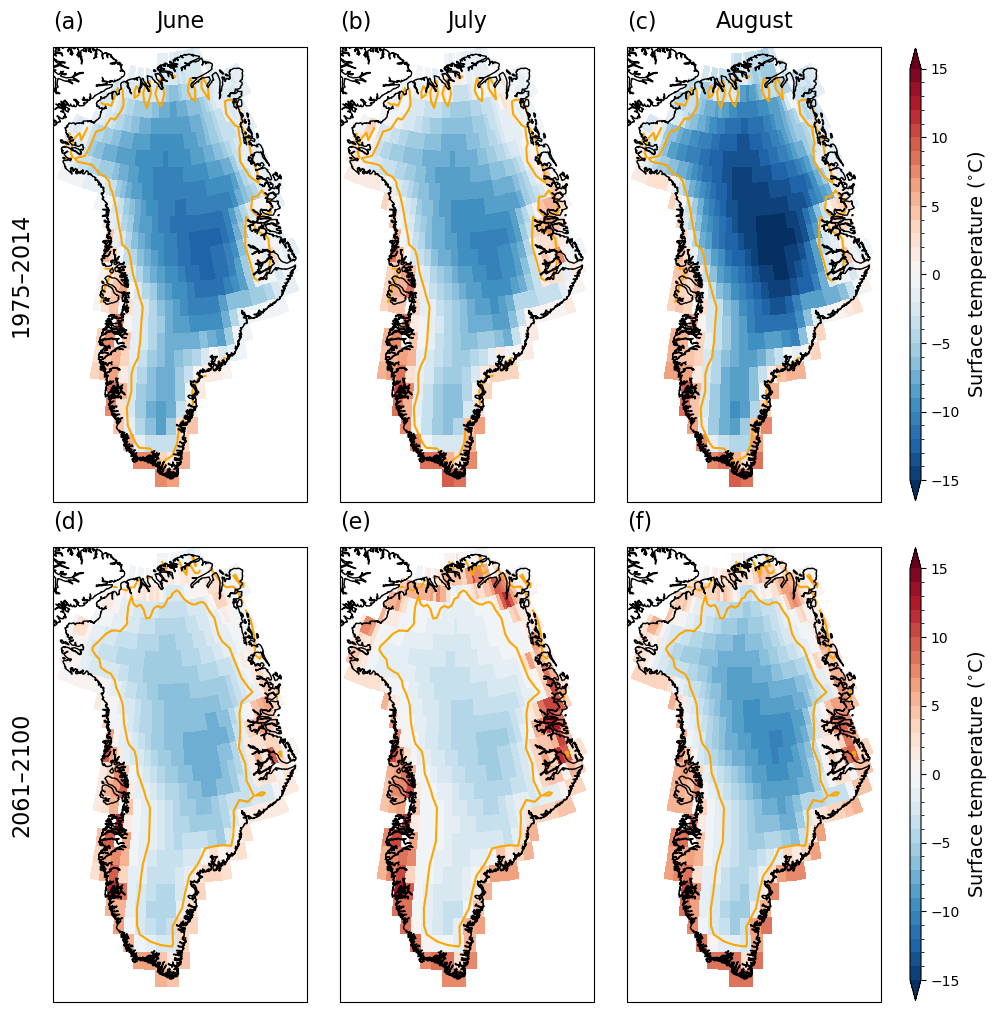

In [23]:
# TS
fig = plt.figure(figsize = (11,12.4))
gs=GridSpec(2,3)
plt.rcParams['axes.titlepad'] =14

# Modify values here
# TS
cmap1 = plt.cm.RdBu_r
bounds1 = np.arange(-15.,15.1,1.)
bounds1min = [-100]
bounds1max = [100]
norm1 = mpl.colors.BoundaryNorm(bounds1, cmap1.N, extend='both')
ticks1 = np.arange(-15.,15.1,5.)

width_line = 1.5

# 1975-2014
ax1 = plt.subplot(gs[0], projection=polar_stereographic)
ax1.set_extent([-56, -30, 58, 84]) # Map bounds, [west, east, south, north]
ax1.coastlines(resolution='10m', zorder=7)
im1 = ax1.pcolormesh(f09_lon, f09_lat, TS_monthly_mean_1975_2014_masked[5]-273.15, cmap=cmap1, norm=norm1, transform=crs_ll)
el1 = ax1.contour(f09_lon, f09_lat, smb_ICE_yearly_mean_1975_2014_ensmean_masked, levels=[0], colors=['orange'], linewidths=width_line, transform=crs_ll)
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.title('(a)', loc='left', fontsize = 16)
plt.title('June', fontsize = 16)

ax1.annotate('1975–2014', xy=(-0.08, 0.5), xycoords='axes fraction',
             rotation=90, va='center', ha='right', annotation_clip=False, fontsize=16)

ax2 = plt.subplot(gs[1], projection=polar_stereographic)
ax2.set_extent([-56, -30, 58, 84])
ax2.coastlines(resolution='10m', zorder=7)
im2 = ax2.pcolormesh(f09_lon, f09_lat, TS_monthly_mean_1975_2014_masked[6]-273.15, cmap=cmap1, norm=norm1, transform=crs_ll)
el2 = ax2.contour(f09_lon, f09_lat, smb_ICE_yearly_mean_1975_2014_ensmean_masked, levels=[0], colors=['orange'], linewidths=width_line, transform=crs_ll)
ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.title('(b)', loc='left', fontsize = 16)
plt.title('July', fontsize = 16)

ax3 = plt.subplot(gs[2], projection=polar_stereographic)
ax3.set_extent([-56, -30, 58, 84])
ax3.coastlines(resolution='10m', zorder=7)
im3 = ax3.pcolormesh(f09_lon, f09_lat, TS_monthly_mean_1975_2014_masked[7]-273.15, cmap=cmap1, norm=norm1, transform=crs_ll)
el3 = ax3.contour(f09_lon, f09_lat, smb_ICE_yearly_mean_1975_2014_ensmean_masked, levels=[0], colors=['orange'], linewidths=width_line, transform=crs_ll)
ax3.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax3.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.title('(c)', loc='left', fontsize = 16)
plt.title('August', fontsize = 16)

# colorbar
cbar_ax = fig.add_axes([0.915, 0.5143, 0.01, 0.365])
cb = fig.colorbar(im1, cax=cbar_ax, orientation='vertical', boundaries=bounds1min+bounds1+bounds1max, ticks=ticks1)
cb.set_label(label='Surface temperature ($\mathregular{^{\circ}}$C)', size=14)
cb.ax.tick_params(labelsize=10)

# dQ
ax4 = plt.subplot(gs[3], projection=polar_stereographic)
ax4.set_extent([-56, -30, 58, 84]) # Map bounds, [west, east, south, north]
ax4.coastlines(resolution='10m', zorder=7)
im4 = ax4.pcolormesh(f09_lon, f09_lat, TS_monthly_mean_2061_2100_masked[5]-273.15, cmap=cmap1, norm=norm1, transform=crs_ll)
el4 = ax4.contour(f09_lon, f09_lat, smb_ICE_yearly_mean_2061_2100_ensmean_masked, levels=[0], colors=['orange'], linewidths=width_line, transform=crs_ll)
ax4.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax4.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.title('(d)', loc='left', fontsize = 16)

ax4.annotate('2061–2100', xy=(-0.08, 0.5), xycoords='axes fraction',
             rotation=90, va='center', ha='right', annotation_clip=False, fontsize=16)

ax5 = plt.subplot(gs[4], projection=polar_stereographic)
ax5.set_extent([-56, -30, 58, 84])
ax5.coastlines(resolution='10m', zorder=7)
im5 = ax5.pcolormesh(f09_lon, f09_lat, TS_monthly_mean_2061_2100_masked[6]-273.15, cmap=cmap1, norm=norm1, transform=crs_ll)
el5 = ax5.contour(f09_lon, f09_lat, smb_ICE_yearly_mean_2061_2100_ensmean_masked, levels=[0], colors=['orange'], linewidths=width_line, transform=crs_ll)
ax5.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax5.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.title('(e)', loc='left', fontsize = 16)
#plt.title('2071-2100', fontsize = 16)

ax6 = plt.subplot(gs[5], projection=polar_stereographic)
ax6.set_extent([-56, -30, 58, 84])
ax6.coastlines(resolution='10m', zorder=7)
im6 = ax6.pcolormesh(f09_lon, f09_lat, TS_monthly_mean_2061_2100_masked[7]-273.15, cmap=cmap1, norm=norm1, transform=crs_ll)
el6 = ax6.contour(f09_lon, f09_lat, smb_ICE_yearly_mean_2061_2100_ensmean_masked, levels=[0], colors=['orange'], linewidths=width_line, transform=crs_ll)
ax6.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax6.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.title('(f)', loc='left', fontsize = 16)
#plt.title('Difference', fontsize = 16)

# colorbar
cbar_ax = fig.add_axes([0.915, 0.1113, 0.01, 0.365])
cb = fig.colorbar(im4, cax=cbar_ax, orientation='vertical', boundaries=bounds1min+bounds1+bounds1max, ticks=ticks1)
cb.set_label(label='Surface temperature ($\mathregular{^{\circ}}$C)', size=14)
cb.ax.tick_params(labelsize=10)


plt.subplots_adjust(#left=0.1,
                    #bottom=0.1,
                    #right=0.9,
                    #top=0.9,
                    wspace=0.03,
                    hspace=0.1)

plt.savefig(home_dir+'2023-GrIS-melt-causality/physics/figS4_map_LENS2_TS_1975-2014_2061-2100_JJA.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)